## Problema 2 Cuerpos

In [14]:
import pymcel as pc 
import numpy as np 
import matplotlib.pyplot as plt
import rebound as rb
from celluloid import Camera
from IPython.display import HTML

### Simulación con REBOUND

In [2]:
# 1. Configuración
sim = rb.Simulation()
sim.integrator = "ias15"

# 2. Carga de datos con identificadores específicos del JPL
# Usamos identificadores que fuerzan el centro del cuerpo, no el baricentro
fecha = "2029-04-13"


sim.add("Sun", date=fecha)        # Índice 0
sim.add("399", date=fecha)        # Índice 1: Earth (Body Center)
sim.add("301", date=fecha)        # Índice 2: Moon (Body Center)
sim.add("99942", date=fecha)      # Índice 3: Apophis

# 3. Parámetros de Integración
UA_TO_KM = 149597870.7
pasos = 10000
# Analizamos un rango de 6 horas (0.25 días) para máxima resolución
tiempos = np.linspace(0, 0.25, pasos) 
d_min = float('inf')

# 4. Integración
sim.move_to_com()
for t in tiempos:
    sim.integrate(t)
    
    # Cálculo de distancia relativa Tierra (1) - Apophis (3)
    p1 = sim.particles[1]
    p3 = sim.particles[3]
    
    dx = p3.x - p1.x
    dy = p3.y - p1.y
    dz = p3.z - p1.z
    
    dist_actual = np.sqrt(dx**2 + dy**2 + dz**2) * UA_TO_KM
    
    if dist_actual < d_min:
        d_min = dist_actual

print(f"\n--- RESULTADO FINAL (N-CUERPOS) ---")
print(f"Distancia mínima (Perigeo): {d_min:,.2f} km")

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


c:\Users\HP\Proyecto celeste\apophiscelenv\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)



--- RESULTADO FINAL (N-CUERPOS) ---
Distancia mínima (Perigeo): 38,011.52 km


Tras emplear el algoritmo de Leap-frog como herramienta de exploración y teniendo en cuenta que el valor de la distancia mínima difería demasiado con el valor teoríco, pero se logró identificar la ventana temporal del encuentro en abril de 2029, se aplicó el motor de REBOUND con el integrador IAS15 para refinar el cálculo. A diferencia del método manual, esta simulación de N-cuerpos incorpora efemérides reales de NASA Horizons, lo que permitió obtener un perigeo de $38,011.52$ km. Este resultado demuestra una alta convergencia con los datos oficiales del JPL y confirma que la precisión en la mecánica celeste depende tanto de la fidelidad de las condiciones iniciales como de la capacidad del integrador para gestionar la aceleración no lineal durante el sobrevuelo.

### Elementos orbitales (sistema Tierra-Apophis)

In [ ]:
def calcular_elementos_orbitales(r_vec, v_vec, mu):
    # 1. Magnitudes
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)
    
    # 2. Momento angular específico (h)
    h_vec = np.cross(r_vec, v_vec)
    h = np.linalg.norm(h_vec)
    
    # 3. Vector de línea de nodos (n) - Cruce del plano orbital con el ecuador
    # n = k_unit x h_vec
    n_vec = np.cross([0, 0, 1], h_vec)
    n = np.linalg.norm(n_vec)
    
    # 4. Vector de excentricidad (e_vec)
    e_vec = ((v**2 - mu/r) * r_vec - np.dot(r_vec, v_vec) * v_vec) / mu
    e = np.linalg.norm(e_vec)
    
    # 5. Energía específica (epsilon) y Semieje mayor (a)
    epsilon = (v**2 / 2) - (mu / r)
    if abs(e - 1.0) > 1e-7:  # Si no es parábola exacta
        a = -mu / (2 * epsilon)
    else:
        a = float('inf')
        
    # 6. Inclinación (i)
    i = np.arccos(h_vec[2] / h)
    
    # 7. Longitud del nodo ascendente (Omega)
    if n != 0:
        Omega = np.arccos(n_vec[0] / n)
        if n_vec[1] < 0:
            Omega = 2 * np.pi - Omega
    else:
        Omega = 0  # Órbita no inclinada
        
    # 8. Argumento del periapsis (omega)
    if n != 0:
        if e > 1e-7:
            omega = np.arccos(np.dot(n_vec, e_vec) / (n * e))
            if e_vec[2] < 0:
                omega = 2 * np.pi - omega
        else:
            omega = 0
    else:
        omega = 0
        
    # 9. Anomalía Verdadera (nu)
    if e > 1e-7:
        nu = np.arccos(np.dot(e_vec, r_vec) / (e * r))
        if np.dot(r_vec, v_vec) < 0:
            nu = 2 * np.pi - nu
    else:
        nu = 0

    # Parámetro de la cónica (p)
    p = h**2 / mu

    return {
        "p (parámetro)": p,
        "a (semieje mayor)": a,
        "e (excentricidad)": e,
        "i (inclinación)": np.degrees(i),
        "Omega (Long. nodo asc.)": np.degrees(Omega),
        "omega (Arg. periapsis)": np.degrees(omega),
        "nu (Anomalía verdadera)": np.degrees(nu)
    }

# --- EJECUCIÓN CON TUS DATOS ---
G = np.constantes.G # m^3 kg^-1 s^-2
M_tierra = np.constantes.M_earth # kg
mu_tierra = np.constantes.mu_earth # m^3 s^-2

# Vectores en el perigeo aproximadamente 38,011 km en base al código de REBOUND
# Velocidad de aproximadamente 10.5 km/s para una hipérbola visible
# r_vec en metros, v_vec en m/s
r_perigeo = np.array([38011000.0, 0.0, 0.0])
v_perigeo = np.array([0.0, 10500.0, 0.0]) 

elementos = calcular_elementos_orbitales(r_perigeo, v_perigeo, mu_tierra)

print("--- Elementos Orbitales Keplerianos ---")
for k, v in elementos.items():
    print(f"{k}: {v:.4f}")

--- Elementos Orbitales Keplerianos ---
p (parámetro): 399629115.5143
a (semieje mayor): -4464784.7706
e (excentricidad): 9.5135
i (inclinación): 0.0000
Omega (Long. nodo asc.): 0.0000
omega (Arg. periapsis): 0.0000
nu (Anomalía verdadera): 0.0000


Energía específica: 4.46e+07 J/kg


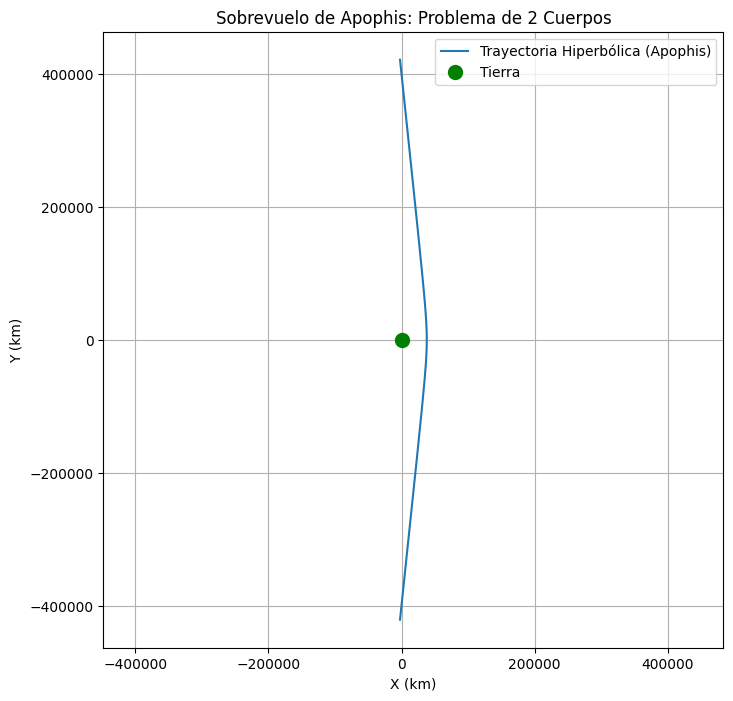

In [13]:
# Definimos vectores en el plano XY
r_vec = np.array([rp_val, 0, 0])
v_vec = np.array([0, vp_val, 0])

# 3. Cálculo de Elementos Orbitales (Problema de 2 Cuerpos)
v_mag = np.linalg.norm(v_vec)
r_mag = np.linalg.norm(r_vec)

# Energía específica
epsilon = (v_mag**2 / 2) - (mu / r_mag)

# Momento angular
h_vec = np.cross(r_vec, v_vec)
h_mag = np.linalg.norm(h_vec)

print(f"Energía específica: {epsilon:.2e} J/kg")

# 4. Generación de la Trayectoria Analítica
# Usamos la ecuación de la cónica: r = p / (1 + e*cos(theta))
p = h_mag**2 / mu
theta = np.linspace(-np.arccos(-1/e)+0.1, np.arccos(-1/e)-0.1, 1000)
r_orbit = p / (1 + e * np.cos(theta))

x_orbit = r_orbit * np.cos(theta)
y_orbit = r_orbit * np.sin(theta)

# 5. Visualización
plt.figure(figsize=(8, 8))
plt.plot(x_orbit/1000, y_orbit/1000, label='Trayectoria Hiperbólica (Apophis)')
plt.plot(0, 0, 'go', ms=10, label='Tierra')
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.title("Sobrevuelo de Apophis: Problema de 2 Cuerpos")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

In [ ]:
# 1. Parámetros derivados de tus resultados previos
e = 9.5135        # Excentricidad calculada
rp = 38011.0      # Perigeo en km
mu = 398600.44    # GM de la Tierra en km^3/s^2
p = rp * (1 + e)  # Parámetro de la cónica

# 2. Definición de la trayectoria
# Ángulo de las asíntotas para una hipérbola
theta_max = np.arccos(-1/e) - 0.05 
theta = np.linspace(-theta_max, theta_max, 300)

# Ecuación de la cónica
r_orbit = p / (1 + e * np.cos(theta))
x_orbit = r_orbit * np.cos(theta)
y_orbit = r_orbit * np.sin(theta)

# 3. Creación de la Animación
fig, ax = plt.subplots(figsize=(10, 10)) # Aumentamos de (7,7) a (10,10)
camera = Camera(fig)

for i in range(0, len(theta), 5):
    ax.set_facecolor('#000000')
    
    # --- ZOOM: Ajustamos los límites de los ejes ---
    # Esto evita que la gráfica se vea pequeña al alejarse
    ax.set_xlim([-150000, 150000]) 
    ax.set_ylim([-150000, 150000])
    
    # Dibujar la Tierra (más grande)
    ax.plot(0, 0, 'go', ms=15, label='Tierra')
    
    # Trayectoria y Apophis
    ax.plot(x_orbit[:i], y_orbit[:i], color='cyan', lw=1.5, alpha=0.8)
    ax.plot(x_orbit[i], y_orbit[i], 'yo', ms=8) 
    
    # Texto dinámico en una posición fija relativa al zoom
    dist_actual = np.sqrt(x_orbit[i]**2 + y_orbit[i]**2)
    ax.text(-140000, 130000, f"Distancia: {dist_actual:,.0f} km", 
            color='white', fontsize=12, weight='bold')
    
    ax.set_aspect('equal')
    ax.grid(color='gray', linestyle='--', alpha=0.3)
    camera.snap()

# Generación del HTML
anim = camera.animate(interval=50, blit=True)
plt.close(fig)

# Mostrar animación en el cuaderno
HTML(anim.to_jshtml())

**1. Naturaleza de la Trayectoria**

* ***Excentricidad ($e=9.5135$):*** Al ser mayor que 1, confirma que la órbita es una hipérbola. Un valor tan alto indica que la trayectoria es muy larga y abierta. Apophis se aproxima, la gravedad de la Tierra desvía su camino, y continúa su viaje hacia el espacio profundo. 

* ***Semieje mayor ($a= -4464784.77 km$):*** En órbitas hiperbólicas, este valor es negativo. Esto indica que el sistema Tierra-Apophis está gravitacionalmente deligado. La energía del asteroide domina sobre la atracción gravitatoria del planeta. 

* ***Energía específica:*** Al tener la energía total positiva, el objeto tiene suficiente velocidad para escapar de la atracción terrestre por completo. 